In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.ticker as mtick
from matplotlib.ticker import ScalarFormatter
from matplotlib.collections import PathCollection
from dataclasses import dataclass
from typing import Tuple, List

In [2]:
raw_data = pd.read_csv("../data/raw_data_all_locations.csv")
raw_data

,Date,Bird,Time,LeftPecks,RightPecks,LeftSeed,RightSeed,source_sheet,Notes,CoolDown
0,2025-10-05,Great tit,12:56:00,NaN,NaN,NaN,NaN,southampton_uk,NaN,NaN
1,2025-10-05,Great tit,16:58:00,NaN,NaN,NaN,NaN,southampton_uk,NaN,NaN
2,2025-10-06,Great tit,09:17:00,NaN,NaN,NaN,NaN,southampton_uk,NaN,NaN
3,2025-10-06,Great tit,11:59:00,NaN,NaN,NaN,NaN,southampton_uk,NaN,NaN
4,2025-10-06,Great tit,14:15:00,NaN,NaN,NaN,NaN,southampton_uk,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
50039,2026-01-18,Northern Cardinal,16:19:00,NaN,NaN,Mix,Mix,essex_fells_nj_07021,NaN,1 min
50040,2026-01-18,Northern Cardinal,16:20:00,NaN,NaN,Mix,Mix,essex_fells_nj_07021,NaN,1 min
50041,2026-01-18,Northern Cardinal,16:22:00,NaN,NaN,Mix,Mix,essex_fells_nj_07021,NaN,1 min
50042,2026-01-18,Northern Cardinal,16:23:00,NaN,NaN,Mix,Mix,essex_fells_nj_07021,NaN,1 min


## Proportion of visits with peck switches

In [3]:
peck_data = raw_data.dropna(subset=['LeftPecks', 'RightPecks'])[['Date', 'Bird', 'Time', 'LeftPecks', 'RightPecks']].reset_index(drop=True)
peck_both = []

for i in range(len(peck_data)):
    left = peck_data.loc[i, 'LeftPecks'] > 0
    right = peck_data.loc[i, 'RightPecks'] > 0
    if left and right:
        peck_both.append(1)
    else:
        peck_both.append(0)
peck_data['peck_both'] = peck_both
peck_both = pd.DataFrame(peck_data.groupby('Bird')['peck_both'].sum()).reset_index()
count_df = peck_data.value_counts('Bird').reset_index()
count_dict = dict(zip(count_df['Bird'], count_df['count']))

peck_both['count'] = peck_both['Bird'].map(count_dict)
peck_both['proportion'] = peck_both['peck_both'] / peck_both['count']
peck_both.sort_values('proportion', ascending=False, inplace=True)
peck_both.reset_index(drop=True, inplace=True)

peck_both

,Bird,peck_both,count,proportion
0,Yellow-rumped Warbler,48,152,0.315789
1,Common Ground Dove,12,71,0.169014
2,Pine Warbler,10,62,0.161290
3,Carolina Wren,91,809,0.112485
4,Eastern Bluebird,78,808,0.096535
5,Mourning Dove,269,4742,0.056727
6,Red-bellied Woodpecker,14,328,0.042683
7,Northern Cardinal,125,3013,0.041487
8,Tufted Titmouse,24,1309,0.018335
9,Carolina Chickadee,9,973,0.009250


In [4]:
time_sampling = raw_data[['Date', 'Time', 'Bird', 'source_sheet']]
time_sampling

,Date,Time,Bird,source_sheet
0,2025-10-05,12:56:00,Great tit,southampton_uk
1,2025-10-05,16:58:00,Great tit,southampton_uk
2,2025-10-06,09:17:00,Great tit,southampton_uk
3,2025-10-06,11:59:00,Great tit,southampton_uk
4,2025-10-06,14:15:00,Great tit,southampton_uk
...,...,...,...,...
50039,2026-01-18,16:19:00,Northern Cardinal,essex_fells_nj_07021
50040,2026-01-18,16:20:00,Northern Cardinal,essex_fells_nj_07021
50041,2026-01-18,16:22:00,Northern Cardinal,essex_fells_nj_07021
50042,2026-01-18,16:23:00,Northern Cardinal,essex_fells_nj_07021


In [5]:
# Config
@dataclass(frozen=True)
class SamplingConfig:
    # Sampling effort
    window_minutes: int = 10          # length of each sampling window (bin size)
    windows_per_day: int = 1          # number of bins/day to sample

    # Randomness
    seed: int = 13126

    # Evaluation
    min_days_required: int = 7        # skip site if not enough days

    # Random strategy stability (optional)
    random_repeats: int = 1           # >1 = repeat random sampling and average metrics per site/setting


# Preprocess
def prepare_df(raw: pd.DataFrame) -> pd.DataFrame:
    """
    Robust parsing:
    - Coerce Date/Time parsing errors to NaT and drop invalid rows.
    - Create minute_of_day as int [0..1439].
    """
    df = raw.copy()

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce").dt.date

    # robust time parsing
    t = pd.to_datetime(df["Time"].astype(str), errors="coerce")
    df["minute_of_day"] = t.dt.hour * 60 + t.dt.minute

    df["Bird"] = df["Bird"].astype(str).str.strip()
    df["source_sheet"] = df["source_sheet"].astype(str).str.strip()

    # drop rows we cannot place in time
    df = df.dropna(subset=["Date", "minute_of_day", "Bird", "source_sheet"]).copy()
    df["minute_of_day"] = df["minute_of_day"].astype(int)

    return df

def add_time_bins(df: pd.DataFrame, cfg: SamplingConfig) -> pd.DataFrame:
    """
    Convert event times into bins of size cfg.window_minutes.
    IMPORTANT: availability is ONLY bins that have events (BirdFy is event-triggered).
    """
    out = df.copy()
    bin_minutes = cfg.window_minutes

    out["bin"] = (out["minute_of_day"] // bin_minutes).astype(int)
    out["bin_start_minute"] = (out["bin"] * bin_minutes).astype(int)
    return out

def build_bin_panel(df_site: pd.DataFrame, cfg: SamplingConfig) -> pd.DataFrame:
    """
    Returns bin-level counts per species for each day, using ONLY bins that contain >=1 event.
    Index columns: Date, bin
    Value columns: species counts (wide)
    Also includes total detections per bin and bin_start_minute.
    """
    # counts per (Date, bin, Bird)
    c = (
        df_site.groupby(["Date", "bin", "Bird"])
        .size()
        .rename("count")
        .reset_index()
    )

    # wide species matrix at bin resolution
    wide = (
        c.pivot_table(index=["Date", "bin"], columns="Bird", values="count", aggfunc="sum", fill_value=0)
        .reset_index()
    )

    # total detections per bin
    species_cols = [col for col in wide.columns if col not in ("Date", "bin")]
    wide["total_detections"] = wide[species_cols].sum(axis=1)

    # convenience: start minute of bin
    wide["bin_start_minute"] = (wide["bin"] * cfg.window_minutes).astype(int)

    return wide


# Sampling strategies (BIN-BASED)
def sample_fixed_time(panel: pd.DataFrame, cfg: SamplingConfig, start_minute: int) -> pd.DataFrame:
    """
    BIN-BASED fixed time:
    - Choose the same start_minute bin each day (and then subsequent bins if windows_per_day>1).
    - If a chosen bin doesn't exist that day (no events in that bin), it contributes nothing.
    """
    bin_minutes = cfg.window_minutes
    start_bin = start_minute // bin_minutes

    sel = []
    for d, g in panel.groupby("Date", sort=False):
        available_bins = set(g["bin"].tolist())
        n_avail = len(available_bins)

        if cfg.windows_per_day >= n_avail:
            # Requesting at least as many windows as exist → take all bins (full coverage)
            chosen_bins = list(available_bins)
        else:
            chosen_bins = []
            for k in range(cfg.windows_per_day):
                b = start_bin + k  # systematic adjacent bins
                if b in available_bins:
                    chosen_bins.append(b)

        if chosen_bins:
            sel.append(g[g["bin"].isin(chosen_bins)].assign(sampled=1))

    out = pd.concat(sel, ignore_index=True) if sel else panel.head(0).assign(sampled=1)
    return out

def sample_random_time(panel: pd.DataFrame, cfg: SamplingConfig, seed: int | None = None) -> pd.DataFrame:
    """
    BIN-BASED random time:
    - For each day, choose windows_per_day random bins among bins that exist that day.
    """
    rng = np.random.default_rng(cfg.seed if seed is None else seed)
    sel = []

    for d, g in panel.groupby("Date", sort=False):
        bins = g["bin"].unique()
        if len(bins) == 0:
            continue

        k = min(cfg.windows_per_day, len(bins))
        chosen = rng.choice(bins, size=k, replace=False)
        sel.append(g[g["bin"].isin(chosen)].assign(sampled=1))

    out = pd.concat(sel, ignore_index=True) if sel else panel.head(0).assign(sampled=1)
    return out


# Truth + metrics
def daily_truth_from_panel(panel: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    species_cols = [c for c in panel.columns if c not in ("Date", "bin", "bin_start_minute", "total_detections")]
    truth = (
        panel.groupby("Date")[species_cols + ["total_detections"]]
        .sum()
        .reset_index()
    )
    truth["species_richness"] = (truth[species_cols] > 0).sum(axis=1)
    return truth, species_cols


def jaccard_presence(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter / union) if union > 0 else 1.0


def bray_curtis(a: np.ndarray, b: np.ndarray) -> float:
    denom = (a + b).sum()
    num = np.abs(a - b).sum()
    return float(1 - (num / denom)) if denom > 0 else 1.0


def evaluate_strategy(panel_full: pd.DataFrame, sample_panel: pd.DataFrame, cfg: SamplingConfig) -> pd.DataFrame:
    """
    Evaluate sampled bins against full bin-truth.
    NOTE: Effort is measured in BINS (not minutes), since availability is "bins with events".
    """
    truth, species_cols = daily_truth_from_panel(panel_full)

    sampled = (
        sample_panel.groupby("Date")[species_cols + ["total_detections"]]
        .sum()
        .reset_index()
    )
    sampled["species_richness"] = (sampled[species_cols] > 0).sum(axis=1)

    # bins available vs sampled (effort)
    avail = panel_full.groupby("Date")["bin"].nunique().rename("bins_available").reset_index()
    bins_s = sample_panel.groupby("Date")["bin"].nunique().rename("bins_sampled").reset_index()

    scored = truth.merge(sampled, on="Date", how="left", suffixes=("_true", "_samp")).fillna(0)
    scored = scored.merge(avail, on="Date", how="left").merge(bins_s, on="Date", how="left").fillna({"bins_sampled": 0})

    scored["sampling_fraction"] = scored["bins_sampled"] / scored["bins_available"].replace(0, np.nan)

    # Errors
    scored["total_abs_err"] = (scored["total_detections_samp"] - scored["total_detections_true"]).abs()
    scored["total_ape"] = np.where(
        scored["total_detections_true"] > 0,
        scored["total_abs_err"] / scored["total_detections_true"],
        np.nan
    )
    scored["richness_abs_err"] = (scored["species_richness_samp"] - scored["species_richness_true"]).abs()

    # Community similarity per day (vectorized over rows)
    true_arr = scored[[f"{c}_true" for c in species_cols]].to_numpy(dtype=float)
    samp_arr = scored[[f"{c}_samp" for c in species_cols]].to_numpy(dtype=float)
    jaccards = np.array([jaccard_presence(true_arr[i] > 0, samp_arr[i] > 0) for i in range(len(scored))])
    bray_curtises = np.array([bray_curtis(true_arr[i], samp_arr[i]) for i in range(len(scored))])
    scored["jaccard"] = jaccards
    scored["bray_curtis"] = bray_curtises

    # Aggregate summary
    summary = pd.DataFrame([{
        "days": int(scored.shape[0]),
        "bins_available_mean": float(scored["bins_available"].mean()),
        "bins_sampled_mean": float(scored["bins_sampled"].mean()),
        "sampling_fraction_mean": float(scored["sampling_fraction"].mean()),
        "total_MAE": float(scored["total_abs_err"].mean()),
        "total_MAPE": float(scored["total_ape"].mean(skipna=True)),
        "richness_MAE": float(scored["richness_abs_err"].mean()),
        "jaccard_mean": float(scored["jaccard"].mean()),
        "bray_curtis_mean": float(scored["bray_curtis"].mean()),
    }])

    return summary


# Grid search per site
def grid_search_site(df: pd.DataFrame, site: str, cfg: SamplingConfig,
                     fixed_start_minutes: List[int],
                     panel: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    For one site:
    - builds bin-panel (event bins only) unless panel is provided
    - evaluates fixed-time (bin) starts
    - evaluates random-time (bin) strategy (optionally repeated for stability)
    If panel is provided, it is reused (avoids rebuilding for each k in the grid).
    """
    if panel is None:
        df_site = df[df["source_sheet"] == site].copy()
        if df_site["Date"].nunique() < cfg.min_days_required:
            return pd.DataFrame()
        df_site = add_time_bins(df_site, cfg)
        panel = build_bin_panel(df_site, cfg)
    if panel.empty:
        return pd.DataFrame()

    results = []

    # Fixed-time variants
    for start in fixed_start_minutes:
        samp = sample_fixed_time(panel, cfg, start_minute=start)
        s = evaluate_strategy(panel, samp, cfg)
        s["site"] = site
        s["strategy"] = "fixed_time_bins"
        s["start_minute"] = start
        results.append(s)

    # Random-time variants (repeat for stability if desired)
    reps = max(1, int(cfg.random_repeats))
    random_rows = []
    for r in range(reps):
        samp = sample_random_time(panel, cfg, seed=cfg.seed + r)
        s = evaluate_strategy(panel, samp, cfg)
        random_rows.append(s)

    s_rand = pd.concat(random_rows, ignore_index=True).mean(numeric_only=True).to_frame().T
    s_rand["site"] = site
    s_rand["strategy"] = "random_time_bins"
    s_rand["start_minute"] = np.nan
    results.append(s_rand)

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

In [6]:
df = prepare_df(time_sampling)

cfg = SamplingConfig(
    window_minutes=10,
    windows_per_day=1,
    seed=13126,
    min_days_required=7,
    random_repeats=25,   # optional; 1 is fine to start
)

fixed_starts = [h * 60 for h in range(0, 24)]  # 00:00..23:00

all_sites = df["source_sheet"].unique().tolist()
out = []
for site in all_sites:
    out.append(grid_search_site(df, site, cfg, fixed_start_minutes=fixed_starts))

results = pd.concat(out, ignore_index=True)
results


/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_42199/3090296081.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t = pd.to_datetime(df["Time"].astype(str), errors="coerce")


,days,bins_available_mean,bins_sampled_mean,sampling_fraction_mean,total_MAE,total_MAPE,richness_MAE,jaccard_mean,bray_curtis_mean,site,strategy,start_minute
0,91.0,37.164835,0.065934,0.055117,224.395604,0.945019,4.835165,0.056777,0.055016,southampton_uk,fixed_time_bins,0.0
1,91.0,37.164835,0.054945,0.054945,224.406593,0.945055,4.846154,0.054945,0.054945,southampton_uk,fixed_time_bins,60.0
2,91.0,37.164835,0.054945,0.054945,224.406593,0.945055,4.846154,0.054945,0.054945,southampton_uk,fixed_time_bins,120.0
3,91.0,37.164835,0.054945,0.054945,224.406593,0.945055,4.846154,0.054945,0.054945,southampton_uk,fixed_time_bins,180.0
4,91.0,37.164835,0.065934,0.055128,224.395604,0.945026,4.835165,0.056777,0.055004,southampton_uk,fixed_time_bins,240.0
...,...,...,...,...,...,...,...,...,...,...,...,...
70,91.0,28.769231,0.054945,0.054945,189.087912,0.945055,5.406593,0.054945,0.054945,essex_fells_nj_07021,fixed_time_bins,1200.0
71,91.0,28.769231,0.054945,0.054945,189.087912,0.945055,5.406593,0.054945,0.054945,essex_fells_nj_07021,fixed_time_bins,1260.0
72,91.0,28.769231,0.054945,0.054945,189.087912,0.945055,5.406593,0.054945,0.054945,essex_fells_nj_07021,fixed_time_bins,1320.0
73,91.0,28.769231,0.054945,0.054945,189.087912,0.945055,5.406593,0.054945,0.054945,essex_fells_nj_07021,fixed_time_bins,1380.0


In [7]:
# Pareto utilities
def pareto_front(df: pd.DataFrame,
                 effort_col: str,
                 score_cols: list[str],
                 maximize: list[bool]) -> pd.DataFrame:
    """
    Return non-dominated rows.

    A row A dominates B if:
      - A is <= B on effort (always minimize effort)
      - and for every score col:
           if maximize[i] True:  A >= B
           else:                 A <= B
      - and at least one strict inequality holds across (effort + scores)

    This is O(n^2) but fine for modest grids.
    """
    if df.empty:
        return df

    X = df[[effort_col] + score_cols].to_numpy(dtype=float)

    # transform to "minimize all dims" by flipping maximize dims
    # effort already minimize
    X2 = X.copy()
    for j, mx in enumerate(maximize, start=1):  # score dims start at col 1
        if mx:
            X2[:, j] = -X2[:, j]  # maximize -> minimize

    n = X2.shape[0]
    is_dominated = np.zeros(n, dtype=bool)

    for i in range(n):
        if is_dominated[i]:
            continue
        for k in range(n):
            if i == k or is_dominated[i]:
                continue
            # k dominates i if all <= and any <
            if np.all(X2[k] <= X2[i]) and np.any(X2[k] < X2[i]):
                is_dominated[i] = True

    return df.loc[~is_dominated].copy()


# Systematic reduction curve (per site)
def _run_one_site_wm(
    site: str,
    wm: int,
    df: pd.DataFrame,
    cfg_base,
    max_windows_cap: int | None,
) -> list:
    """Run grid for one (site, window_minutes); returns list of result DataFrames."""
    df_site = df[df["source_sheet"] == site].copy()
    if df_site["Date"].nunique() < cfg_base.min_days_required:
        return []
    cfg_wm = cfg_base.__class__(
        window_minutes=wm,
        windows_per_day=1,
        seed=cfg_base.seed,
        min_days_required=cfg_base.min_days_required,
        random_repeats=cfg_base.random_repeats,
    )
    df_site_b = add_time_bins(df_site, cfg_wm)
    panel = build_bin_panel(df_site_b, cfg_wm)
    if panel.empty:
        return []
    max_bins = int(panel.groupby("Date")["bin"].nunique().max())
    if max_bins < 1:
        return []
    if max_windows_cap is not None:
        max_bins = min(max_bins, int(max_windows_cap))
    fixed_starts = list(range(0, 1440, wm))
    rows = []
    for k in range(1, max_bins + 1):
        cfg = cfg_base.__class__(
            window_minutes=wm,
            windows_per_day=k,
            seed=cfg_base.seed,
            min_days_required=cfg_base.min_days_required,
            random_repeats=cfg_base.random_repeats,
        )
        res = grid_search_site(
            df=df, site=site, cfg=cfg,
            fixed_start_minutes=fixed_starts,
            panel=panel,
        )
        if res.empty:
            continue
        res["window_minutes"] = wm
        res["windows_per_day"] = k
        res["max_bins_this_wm"] = max_bins
        rows.append(res)
    return rows


def run_reduction_grid_all_k(
    df: pd.DataFrame,
    sites: list[str],
    window_minutes_grid: list[int],
    cfg_base,
    pareto_metric_primary: str = "bray_curtis_mean",
    pareto_metric_secondary: str = "jaccard_mean",
    max_windows_cap: int | None = None,   # optional safety cap if you want it
    n_jobs: int = 1,   # >1 parallelizes over (site, wm) for speed; 1 = serial
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    For each site and each window_minutes:
      - compute max available bins/day (event bins) at that bin width
      - evaluate windows_per_day = 1..max_bins (optionally capped)
      - evaluate fixed-time starts at resolution window_minutes (all possible start bins)
      - evaluate random-time with cfg.random_repeats

    Returns (all_results, pareto_results). Set n_jobs>1 to run (site, wm) in parallel.
    """
    if n_jobs != 1:
        from joblib import Parallel, delayed
        tasks = [(site, wm) for site in sites for wm in window_minutes_grid]
        chunks = Parallel(n_jobs=n_jobs)(
            delayed(_run_one_site_wm)(site, wm, df, cfg_base, max_windows_cap)
            for site, wm in tasks
        )
        all_rows = [r for chunk in chunks for r in chunk]
    else:
        all_rows = []
        for site in sites:
            df_site = df[df["source_sheet"] == site].copy()
            if df_site["Date"].nunique() < cfg_base.min_days_required:
                continue
            for wm in window_minutes_grid:
                cfg_wm = cfg_base.__class__(
                    window_minutes=wm,
                    windows_per_day=1,
                    seed=cfg_base.seed,
                    min_days_required=cfg_base.min_days_required,
                    random_repeats=cfg_base.random_repeats,
                )
                df_site_b = add_time_bins(df_site, cfg_wm)
                panel = build_bin_panel(df_site_b, cfg_wm)
                if panel.empty:
                    continue
                max_bins = int(panel.groupby("Date")["bin"].nunique().max())
                if max_bins < 1:
                    continue
                if max_windows_cap is not None:
                    max_bins = min(max_bins, int(max_windows_cap))
                fixed_starts = list(range(0, 1440, wm))
                for k in range(1, max_bins + 1):
                    cfg = cfg_base.__class__(
                        window_minutes=wm,
                        windows_per_day=k,
                        seed=cfg_base.seed,
                        min_days_required=cfg_base.min_days_required,
                        random_repeats=cfg_base.random_repeats,
                    )
                    res = grid_search_site(
                        df=df, site=site, cfg=cfg,
                        fixed_start_minutes=fixed_starts,
                        panel=panel,
                    )
                    if res.empty:
                        continue
                    res["window_minutes"] = wm
                    res["windows_per_day"] = k
                    res["max_bins_this_wm"] = max_bins
                    all_rows.append(res)

    all_results = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()

    # Pareto front per site (min effort, max fidelity)
    pareto_rows = []
    if not all_results.empty:
        for site, g in all_results.groupby("site", sort=False):
            effort_col = "bins_sampled_mean"
            score_cols = [pareto_metric_primary, pareto_metric_secondary]

            pf = pareto_front(
                g,
                effort_col=effort_col,
                score_cols=score_cols,
                maximize=[True, True],
            )

            pf = pf.sort_values(
                [effort_col, pareto_metric_primary, pareto_metric_secondary],
                ascending=[True, False, False]
            )
            pareto_rows.append(pf)

    pareto_results = pd.concat(pareto_rows, ignore_index=True) if pareto_rows else pd.DataFrame()
    return all_results, pareto_results


# Convenience: pick "best under thresholds" per site
def pick_best_under_thresholds(
    pareto_df: pd.DataFrame,
    min_bray_curtis: float = 0.90,
    min_jaccard: float = 0.80,
) -> pd.DataFrame:
    """
    From Pareto points, choose the lowest-effort option that meets thresholds.
    If none meet thresholds, return the top-scoring (bray then jaccard) Pareto point.
    """
    if pareto_df.empty:
        return pareto_df

    picks = []
    for site, g in pareto_df.groupby("site", sort=False):
        meets = g[(g["bray_curtis_mean"] >= min_bray_curtis) & (g["jaccard_mean"] >= min_jaccard)]
        if not meets.empty:
            choice = meets.sort_values(["bins_sampled_mean", "bray_curtis_mean", "jaccard_mean"],
                                       ascending=[True, False, False]).head(1)
        else:
            choice = g.sort_values(["bray_curtis_mean", "jaccard_mean", "bins_sampled_mean"],
                                   ascending=[False, False, True]).head(1)
        picks.append(choice)

    return pd.concat(picks, ignore_index=True)


In [8]:
cfg_base = SamplingConfig(
    window_minutes=10,   # overridden inside loop
    windows_per_day=1,   # overridden inside loop
    seed=13126,
    min_days_required=7,
    random_repeats=25,
)

sites = df["source_sheet"].unique().tolist()
window_minutes_grid = [5, 10, 15, 30, 60]

all_results, pareto_results = run_reduction_grid_all_k(
    df=df,
    sites=sites,
    window_minutes_grid=window_minutes_grid,
    cfg_base=cfg_base,
    pareto_metric_primary="bray_curtis_mean",
    pareto_metric_secondary="jaccard_mean",
    # max_windows_cap=50,  # optional if runtime gets big
)

pareto_results


,days,bins_available_mean,bins_sampled_mean,sampling_fraction_mean,total_MAE,total_MAPE,richness_MAE,jaccard_mean,bray_curtis_mean,site,strategy,start_minute,window_minutes,windows_per_day,max_bins_this_wm
0,91.0,63.120879,0.043956,0.043956,224.428571,0.956044,4.868132,0.043956,0.043956,southampton_uk,fixed_time_bins,5.0,5,1,120
1,91.0,63.120879,0.043956,0.043956,224.428571,0.956044,4.868132,0.043956,0.043956,southampton_uk,fixed_time_bins,10.0,5,1,120
2,91.0,63.120879,0.043956,0.043956,224.428571,0.956044,4.868132,0.043956,0.043956,southampton_uk,fixed_time_bins,15.0,5,1,120
3,91.0,63.120879,0.043956,0.043956,224.428571,0.956044,4.868132,0.043956,0.043956,southampton_uk,fixed_time_bins,20.0,5,1,120
4,91.0,63.120879,0.043956,0.043956,224.428571,0.956044,4.868132,0.043956,0.043956,southampton_uk,fixed_time_bins,25.0,5,1,120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1853,91.0,7.956044,7.956044,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,essex_fells_nj_07021,fixed_time_bins,1140.0,60,12,12
1854,91.0,7.956044,7.956044,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,essex_fells_nj_07021,fixed_time_bins,1200.0,60,12,12
1855,91.0,7.956044,7.956044,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,essex_fells_nj_07021,fixed_time_bins,1260.0,60,12,12
1856,91.0,7.956044,7.956044,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,essex_fells_nj_07021,fixed_time_bins,1320.0,60,12,12


In [9]:
def _fmt_hhmm(minute: float) -> str:
    if pd.isna(minute):
        return ""
    m = int(minute)
    hh = m // 60
    mm = m % 60
    return f"{hh:02d}:{mm:02d}"


def plot_pareto_subplots_for_site(
    site: str,
    all_results: pd.DataFrame,
    pareto_results: pd.DataFrame,
    metrics: tuple[str, ...] = ("bray_curtis_mean", "jaccard_mean", "total_MAE", "total_MAPE"),
    effort_col: str = "windows_per_day",
    annotate_k: int = 4,
    alpha_all: float = 0.05,
    strategy_palette: list[str] | None = None,
):
    """
    5 rows (metrics) x 5 cols (window_minutes). One metric per row, one window_minutes per column.
    Plots all_results only, with hue = strategy (palette black/red).
    """
    if strategy_palette is None:
        strategy_palette = ["black", "red"]

    g = all_results[all_results["site"] == site].copy()
    pf = pareto_results[pareto_results["site"] == site].copy()

    if g.empty:
        raise ValueError(f"No rows for site={site!r} in all_results.")

    uniq_w = np.sort(g["window_minutes"].dropna().unique())[:5]
    n_w = len(uniq_w)
    if n_w == 0:
        raise ValueError(f"No window_minutes in all_results for site={site!r}.")

    uniq_strat = g["strategy"].dropna().unique()
    strat_to_color = {s: strategy_palette[i % len(strategy_palette)] for i, s in enumerate(uniq_strat)}

    fig, axes = plt.subplots(4, n_w, figsize=(4 * n_w, 13), sharey="row")
    if n_w == 1:
        axes = axes[:, np.newaxis]

    for i, metric in enumerate(metrics):
        for j, w in enumerate(uniq_w):
            ax = axes[i, j]
            gg = g[np.isfinite(g[effort_col]) & np.isfinite(g[metric])]
            if "window_minutes" in gg.columns:
                gg = gg[gg["window_minutes"] == w]

            if gg.empty:
                if i == 0:
                    ax.set_title(f"{int(w)} min")
                if i == 4:
                    ax.set_xlabel("Effort (avg event-bins processed per day)")
                if j == 0:
                    ax.set_ylabel(metric.replace("_", " ").capitalize(), fontsize=30)
                ax.grid(True, alpha=0.25)
                continue

            for strat in uniq_strat:
                mask = gg["strategy"] == strat
                if not mask.any():
                    continue
                ax.scatter(
                    gg.loc[mask, effort_col],
                    gg.loc[mask, metric],
                    c=strat_to_color[strat],
                    alpha=alpha_all,
                    s=10,
                    label=strat,
                )

            if i == 0:
                ax.set_title(f"{int(w)} min")
            if i == 4:
                ax.set_xlabel("Effort\n(Visits Processed)", fontsize=18)
            if j == 0:
                ax.set_ylabel(metric.replace("_", " ").upper(), fontsize=18)
            ax.grid(True, alpha=0.25)

        handles, labels = [], []
        for ax in axes.flat:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)
        uniq = dict(zip(labels, handles))

    fig.suptitle(f"{site.replace('_', ' ').upper()}", y=1, x=0.4, fontsize=26)  # left-aligned
    legend_handles = []
    for h in uniq.values():
        if isinstance(h, PathCollection):
            fc = h.get_facecolors()
            c = fc[0] if fc.size > 0 else h.get_edgecolors()[0]
            proxy = axes.flat[0].scatter([], [], c=[c], s=150, alpha=1, edgecolors="none")
            legend_handles.append(proxy)
        else:
            legend_handles.append(h)
    fig.legend(
        legend_handles, uniq.keys(),
        loc="upper left",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=False,
        fontsize=22,
    )
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    plt.show()

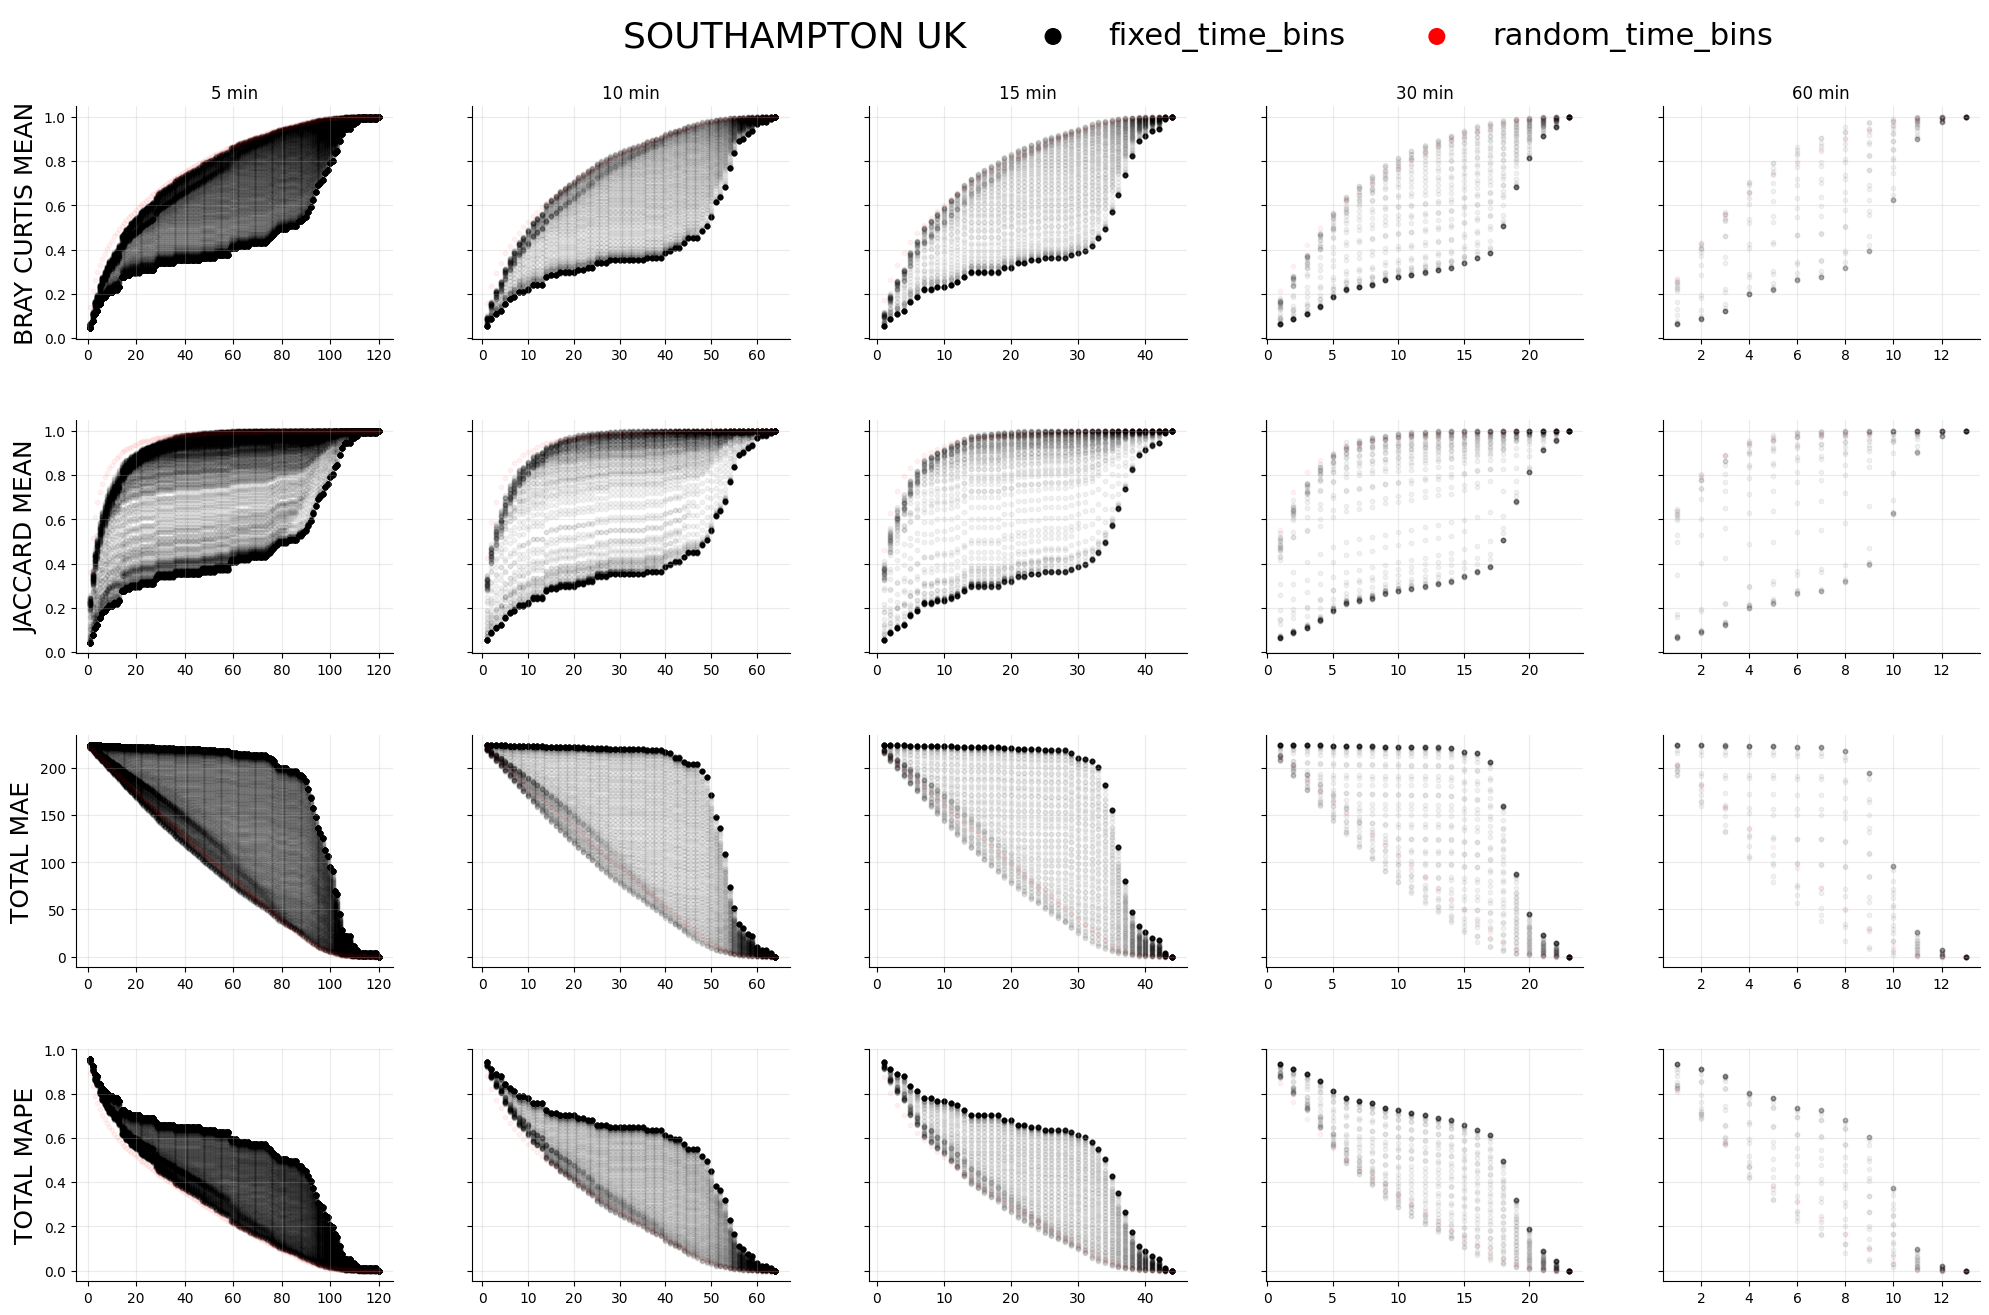

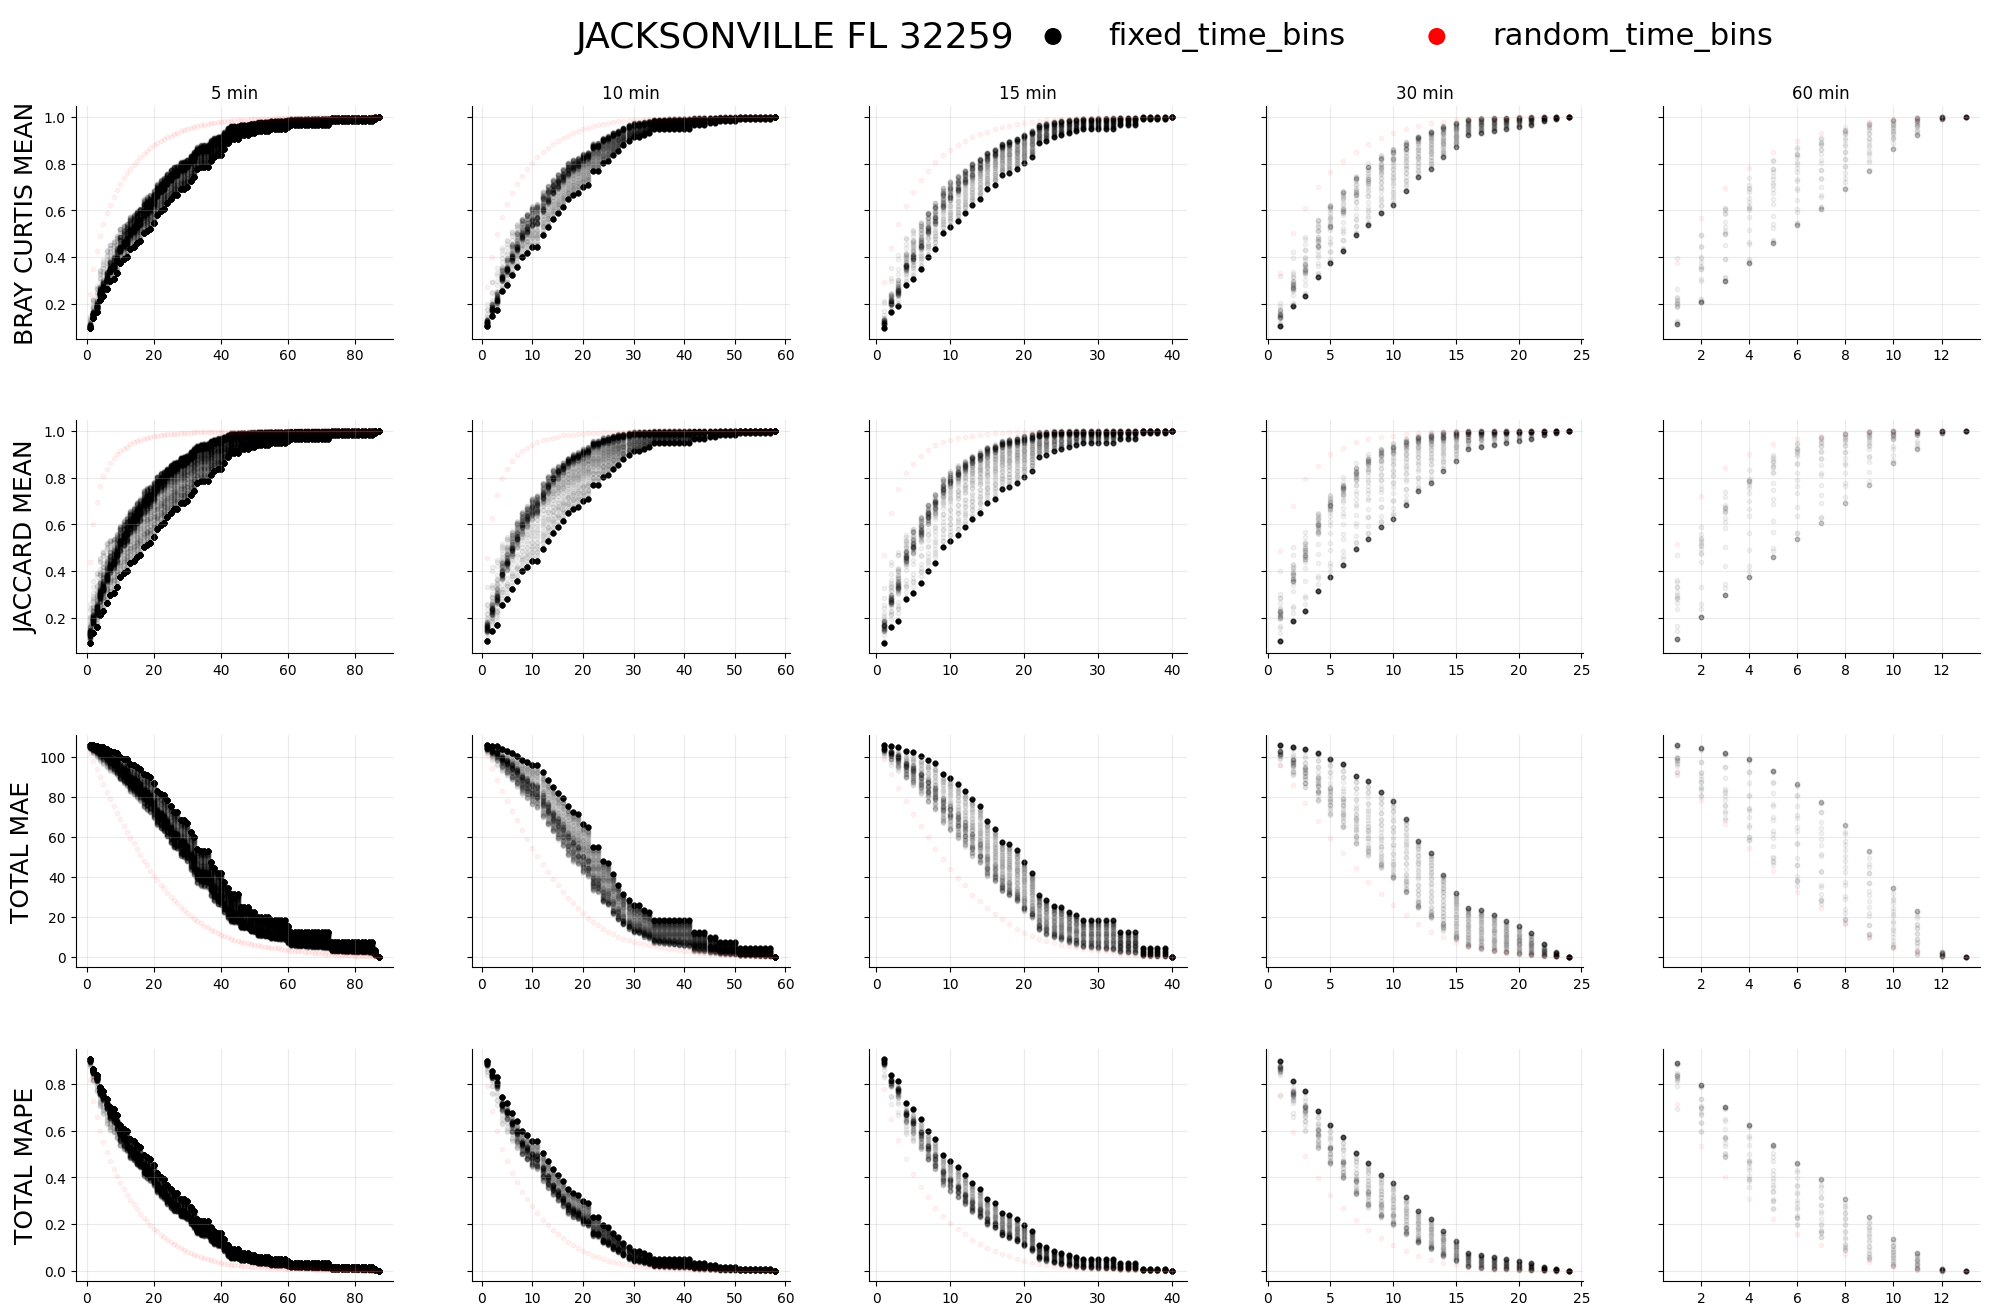

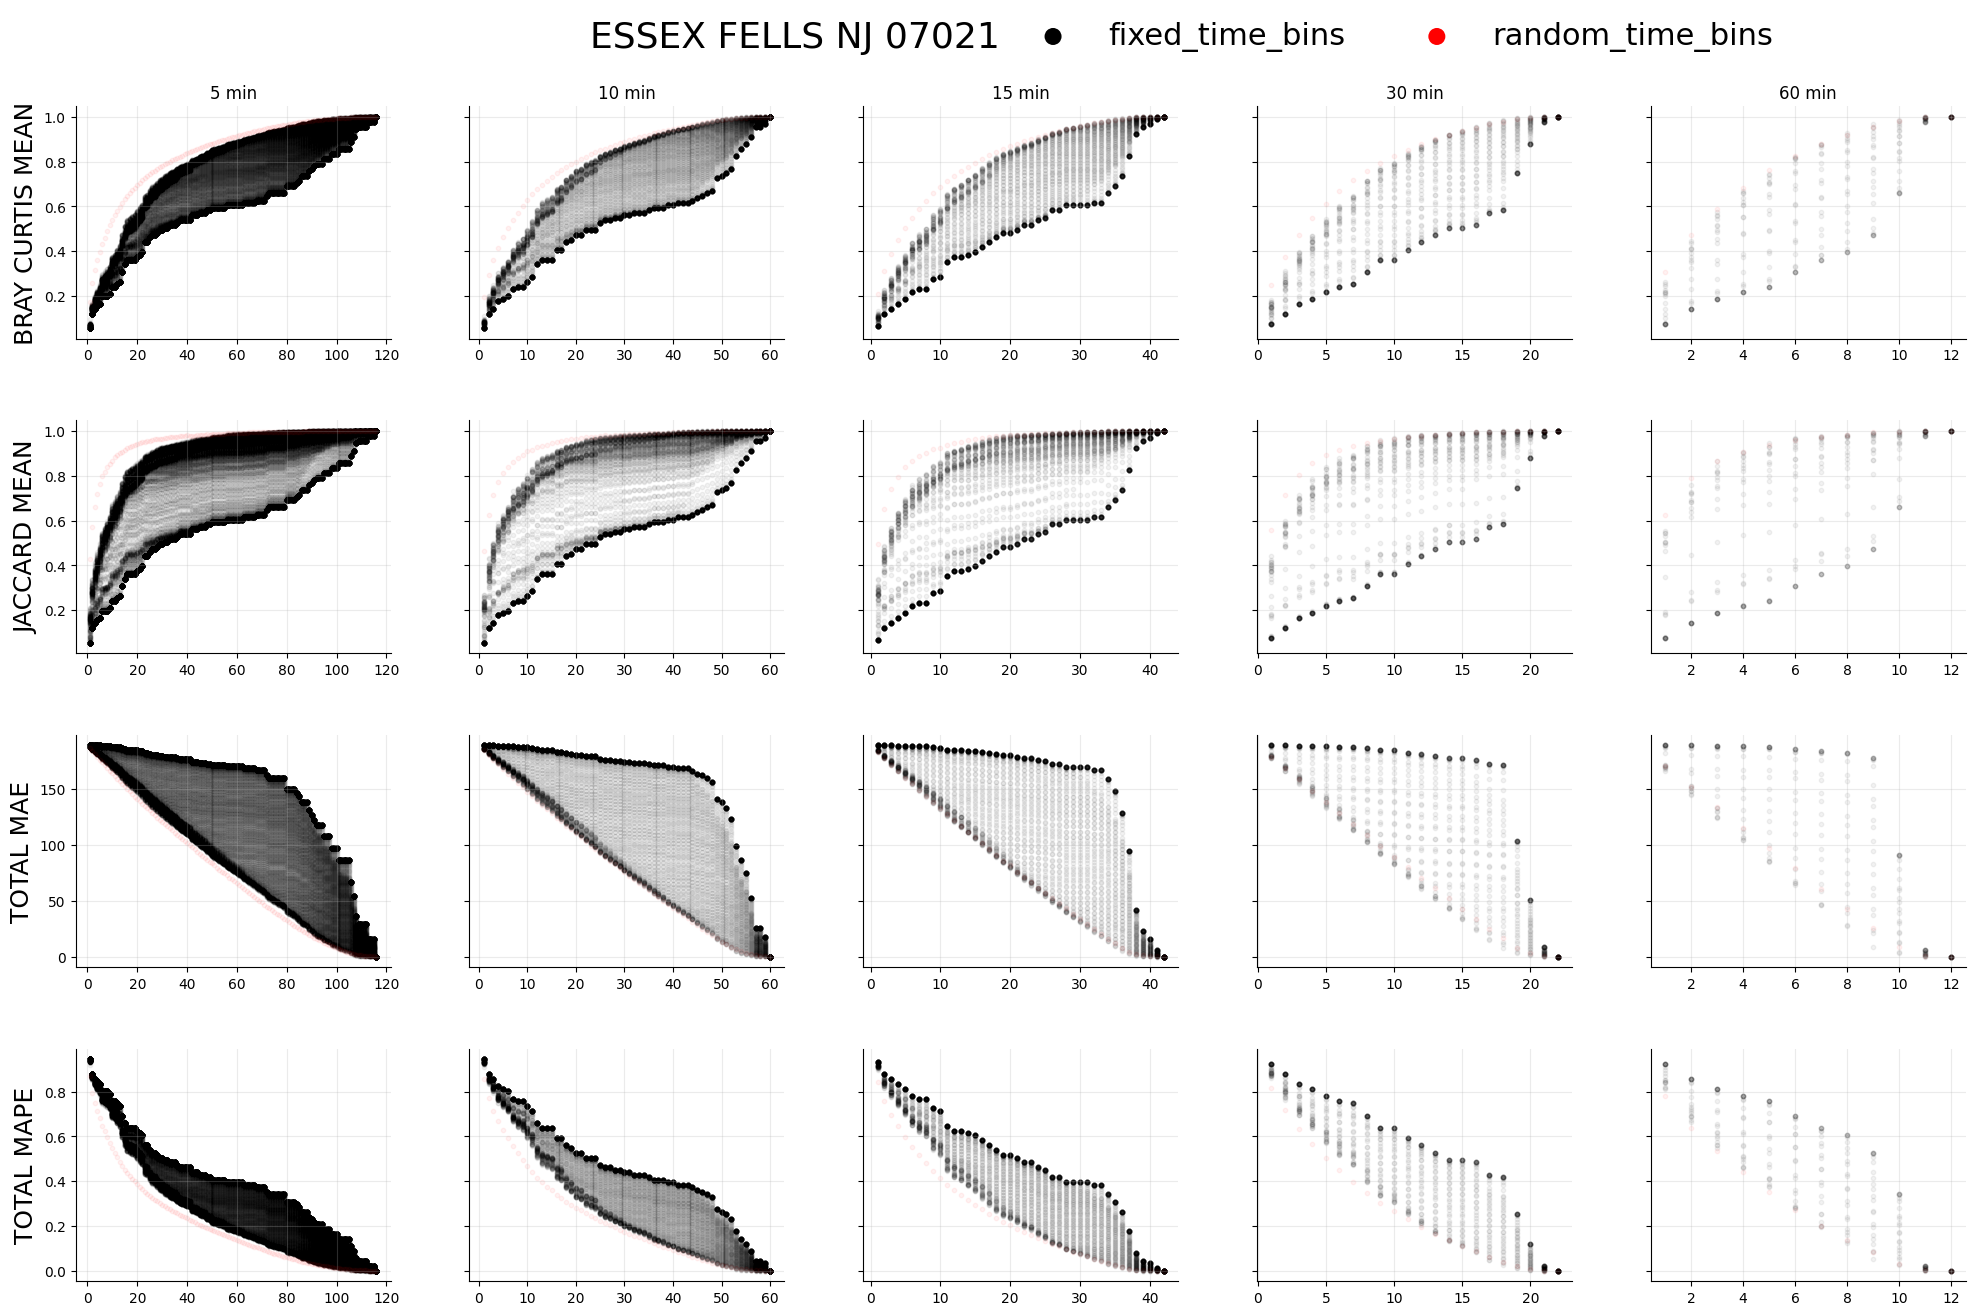

In [10]:
for site in pareto_results["site"].unique():
    plot_pareto_subplots_for_site(site, all_results, pareto_results, annotate_k=5)

In [11]:
from matplotlib.ticker import ScalarFormatter

def _fmt_hhmm(minute: float) -> str:
    if pd.isna(minute):
        return ""
    m = int(minute)
    hh = m // 60
    mm = m % 60
    return f"{hh:02d}:{mm:02d}"


def plot_pareto_subplots_for_site(
    site: str,
    all_results: pd.DataFrame,
    pareto_results: pd.DataFrame,
    metrics: tuple[str, ...] = ("bray_curtis_mean", "jaccard_mean", "total_MAE", "total_MAPE"),
    effort_col: str = "windows_per_day",
    annotate_k: int = 4,
    alpha_all: float = 0.05,
    strategy_palette: list[str] | None = None,
):
    """
    5 rows (metrics) x 5 cols (window_minutes). One metric per row, one window_minutes per column.
    Plots all_results only, with hue = strategy (palette black/red).
    """
    if strategy_palette is None:
        strategy_palette = ["black", "red"]

    g = all_results[all_results["site"] == site].copy()
    pf = pareto_results[pareto_results["site"] == site].copy()

    if g.empty:
        raise ValueError(f"No rows for site={site!r} in all_results.")

    uniq_w = np.sort(g["window_minutes"].dropna().unique())[:5]
    n_w = len(uniq_w)
    if n_w == 0:
        raise ValueError(f"No window_minutes in all_results for site={site!r}.")

    uniq_strat = g["strategy"].dropna().unique()
    strat_to_color = {s: strategy_palette[i % len(strategy_palette)] for i, s in enumerate(uniq_strat)}

    fig, axes = plt.subplots(4, n_w, figsize=(4 * n_w, 13), sharey="row")
    if n_w == 1:
        axes = axes[:, np.newaxis]

    for i, metric in enumerate(metrics):
        for j, w in enumerate(uniq_w):
            ax = axes[i, j]
            gg = g[np.isfinite(g[effort_col]) & np.isfinite(g[metric])]
            if "window_minutes" in gg.columns:
                gg = gg[gg["window_minutes"] == w]

            if gg.empty:
                if i == 0:
                    ax.set_title(f"{int(w)} min")
                if i == 4:
                    ax.set_xlabel("Effort (avg event-bins processed per day)")
                if j == 0:
                    ax.set_ylabel(metric.replace("_", " ").capitalize(), fontsize=30)
                ax.grid(True, alpha=0.25)
                continue

            for strat in uniq_strat:
                mask = gg["strategy"] == strat
                if not mask.any():
                    continue
                sns.kdeplot(
                    data=gg.loc[mask],
                    x=effort_col,
                    y=metric,
                    ax=ax,
                    color=strat_to_color[strat],
                    label=strat,
                    fill=True,
                    alpha=0.3,
                    levels=5,
                )

            if i == 0:
                ax.set_title(f"{int(w)} min")
            if i == 4:
                ax.set_xlabel("Effort\n(Visits Processed)", fontsize=18)
            if j == 0:
                ax.set_ylabel(metric.replace("_", " ").upper(), fontsize=18)
            ax.grid(True, alpha=0.25)

        handles, labels = [], []
    for ax in axes.flat:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    uniq = dict(zip(labels, handles))
    fig.suptitle(f"{site.replace('_', ' ').upper()}", y=1, x=0.4, fontsize=26)  # left-aligned
    fig.legend(
        uniq.values(), uniq.keys(), loc="upper left", 
        bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False, 
        fontsize=26)
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    plt.show()

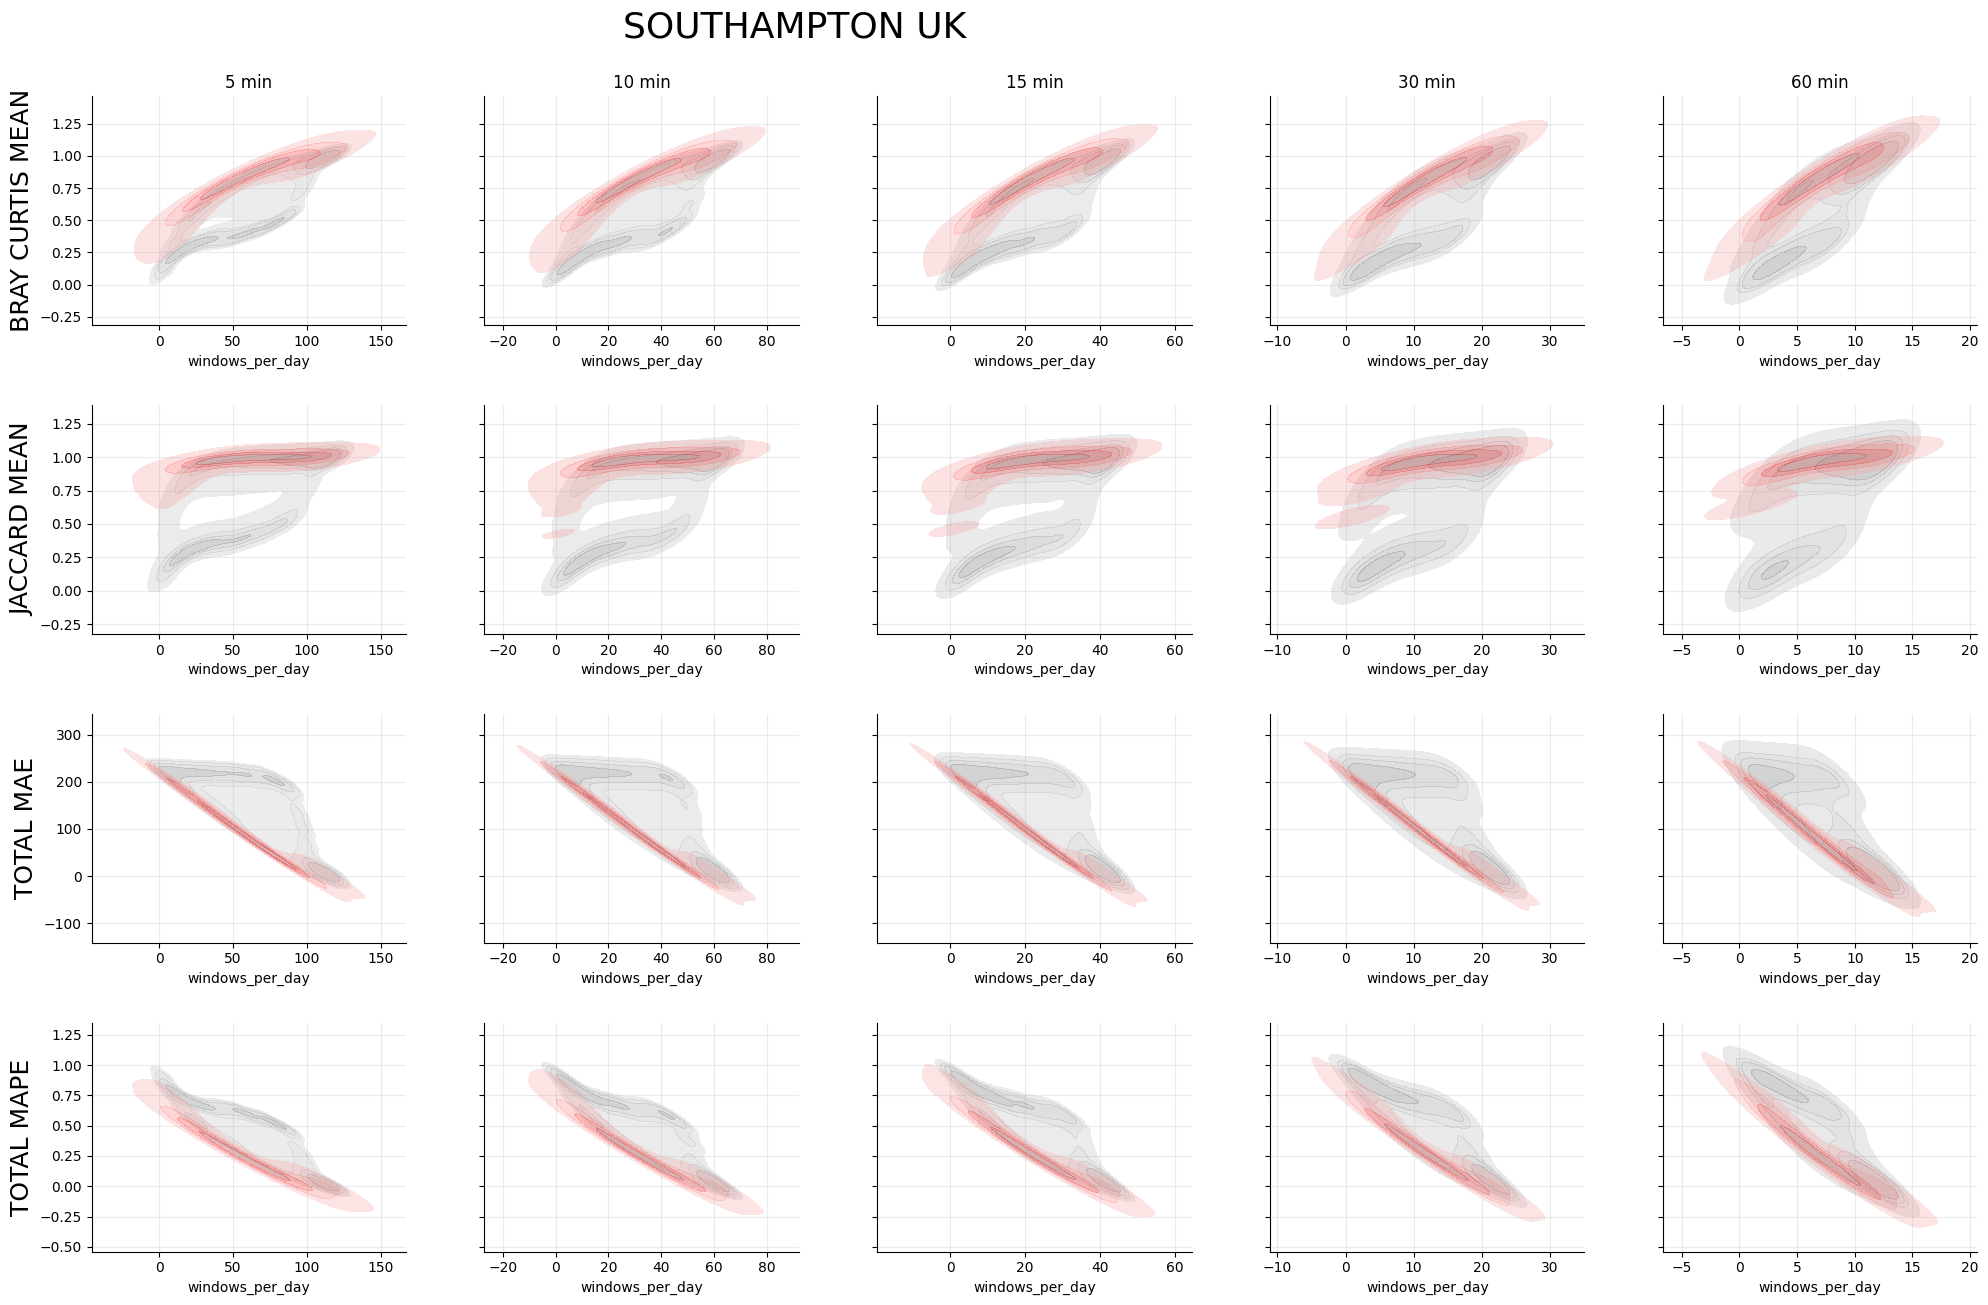

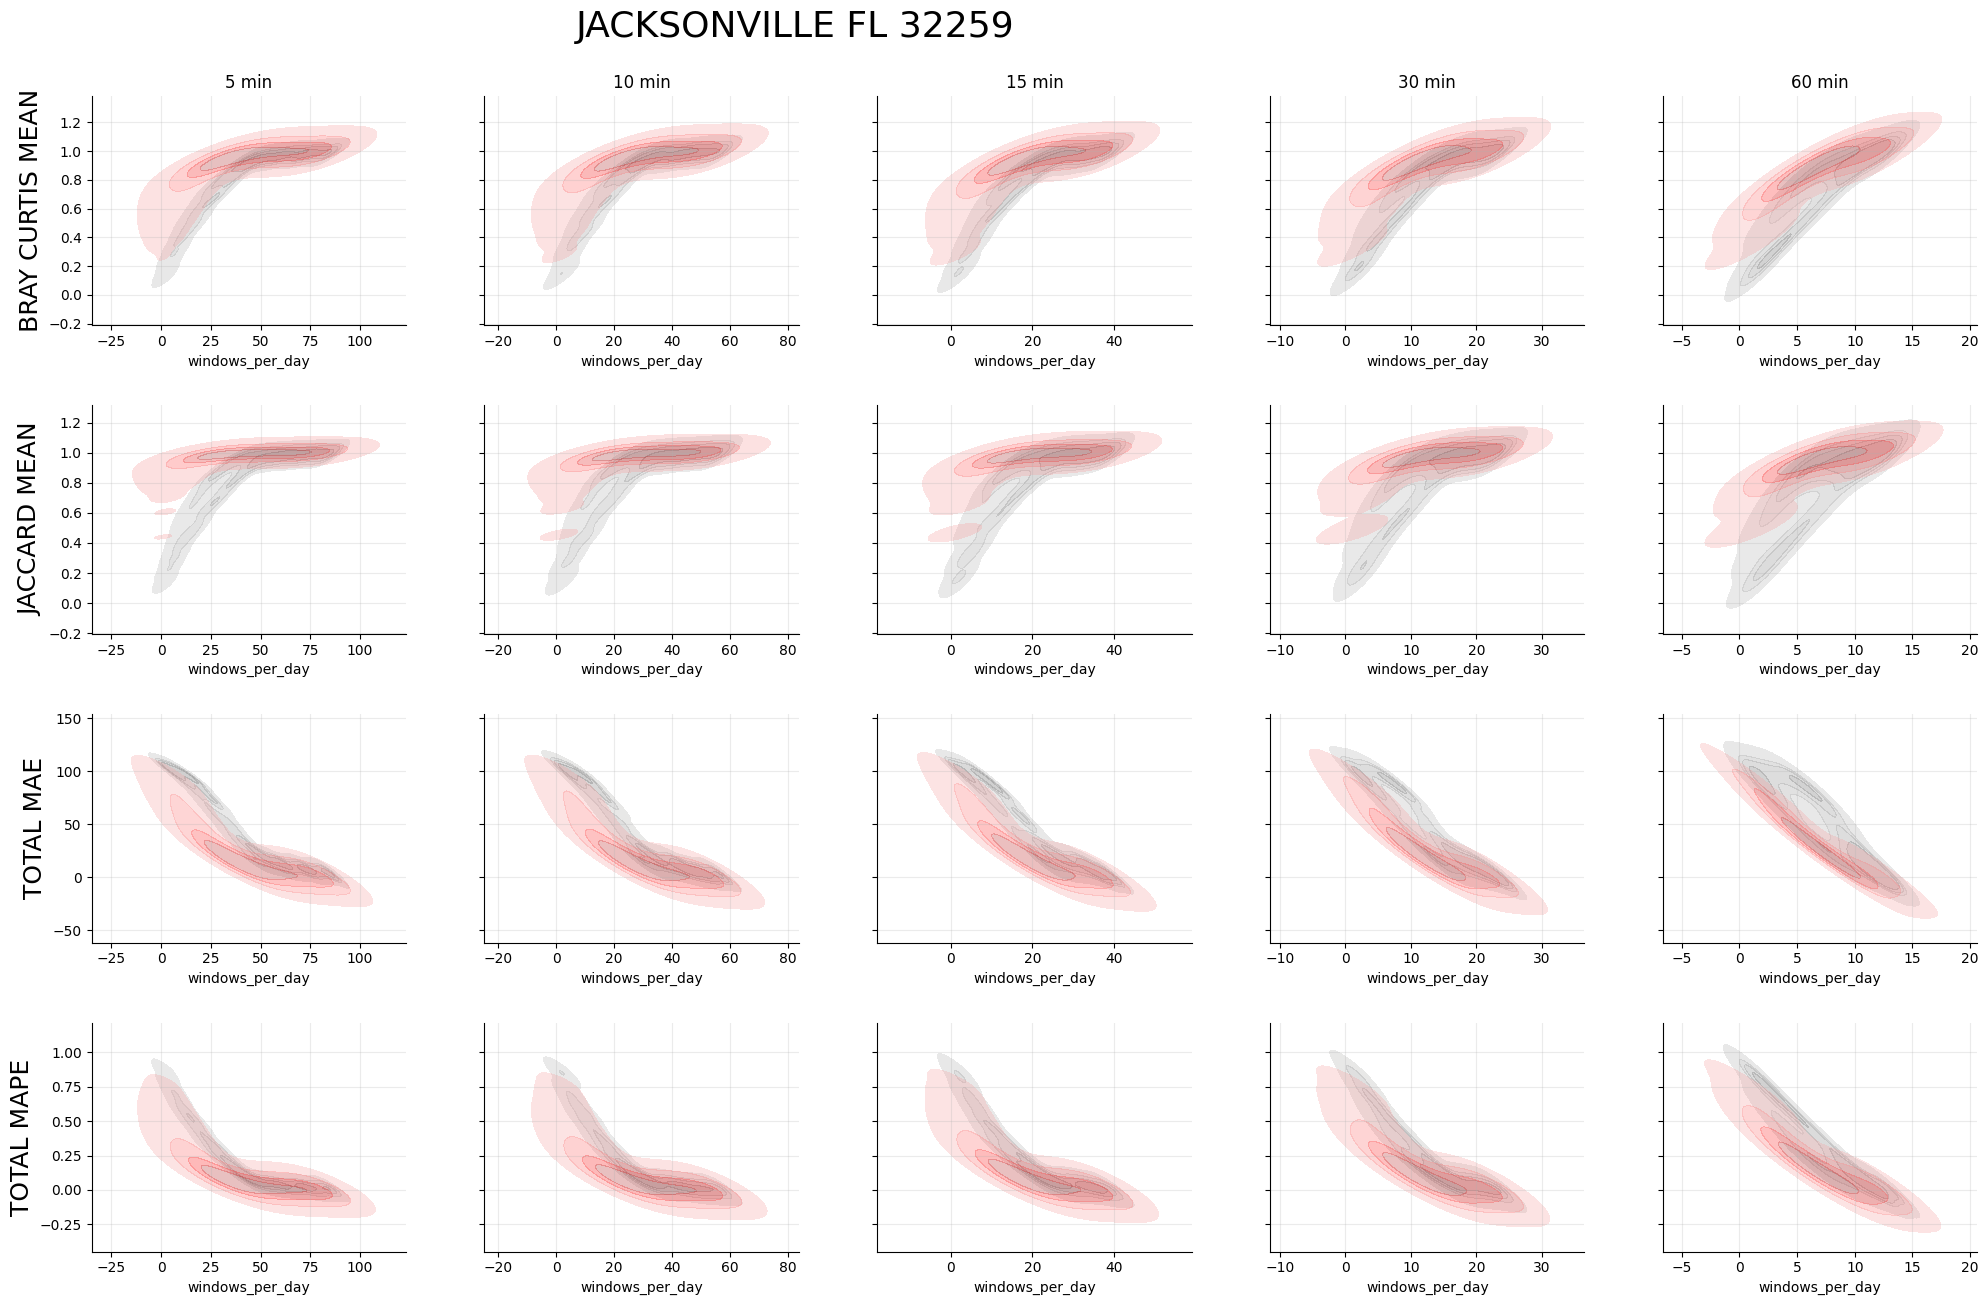

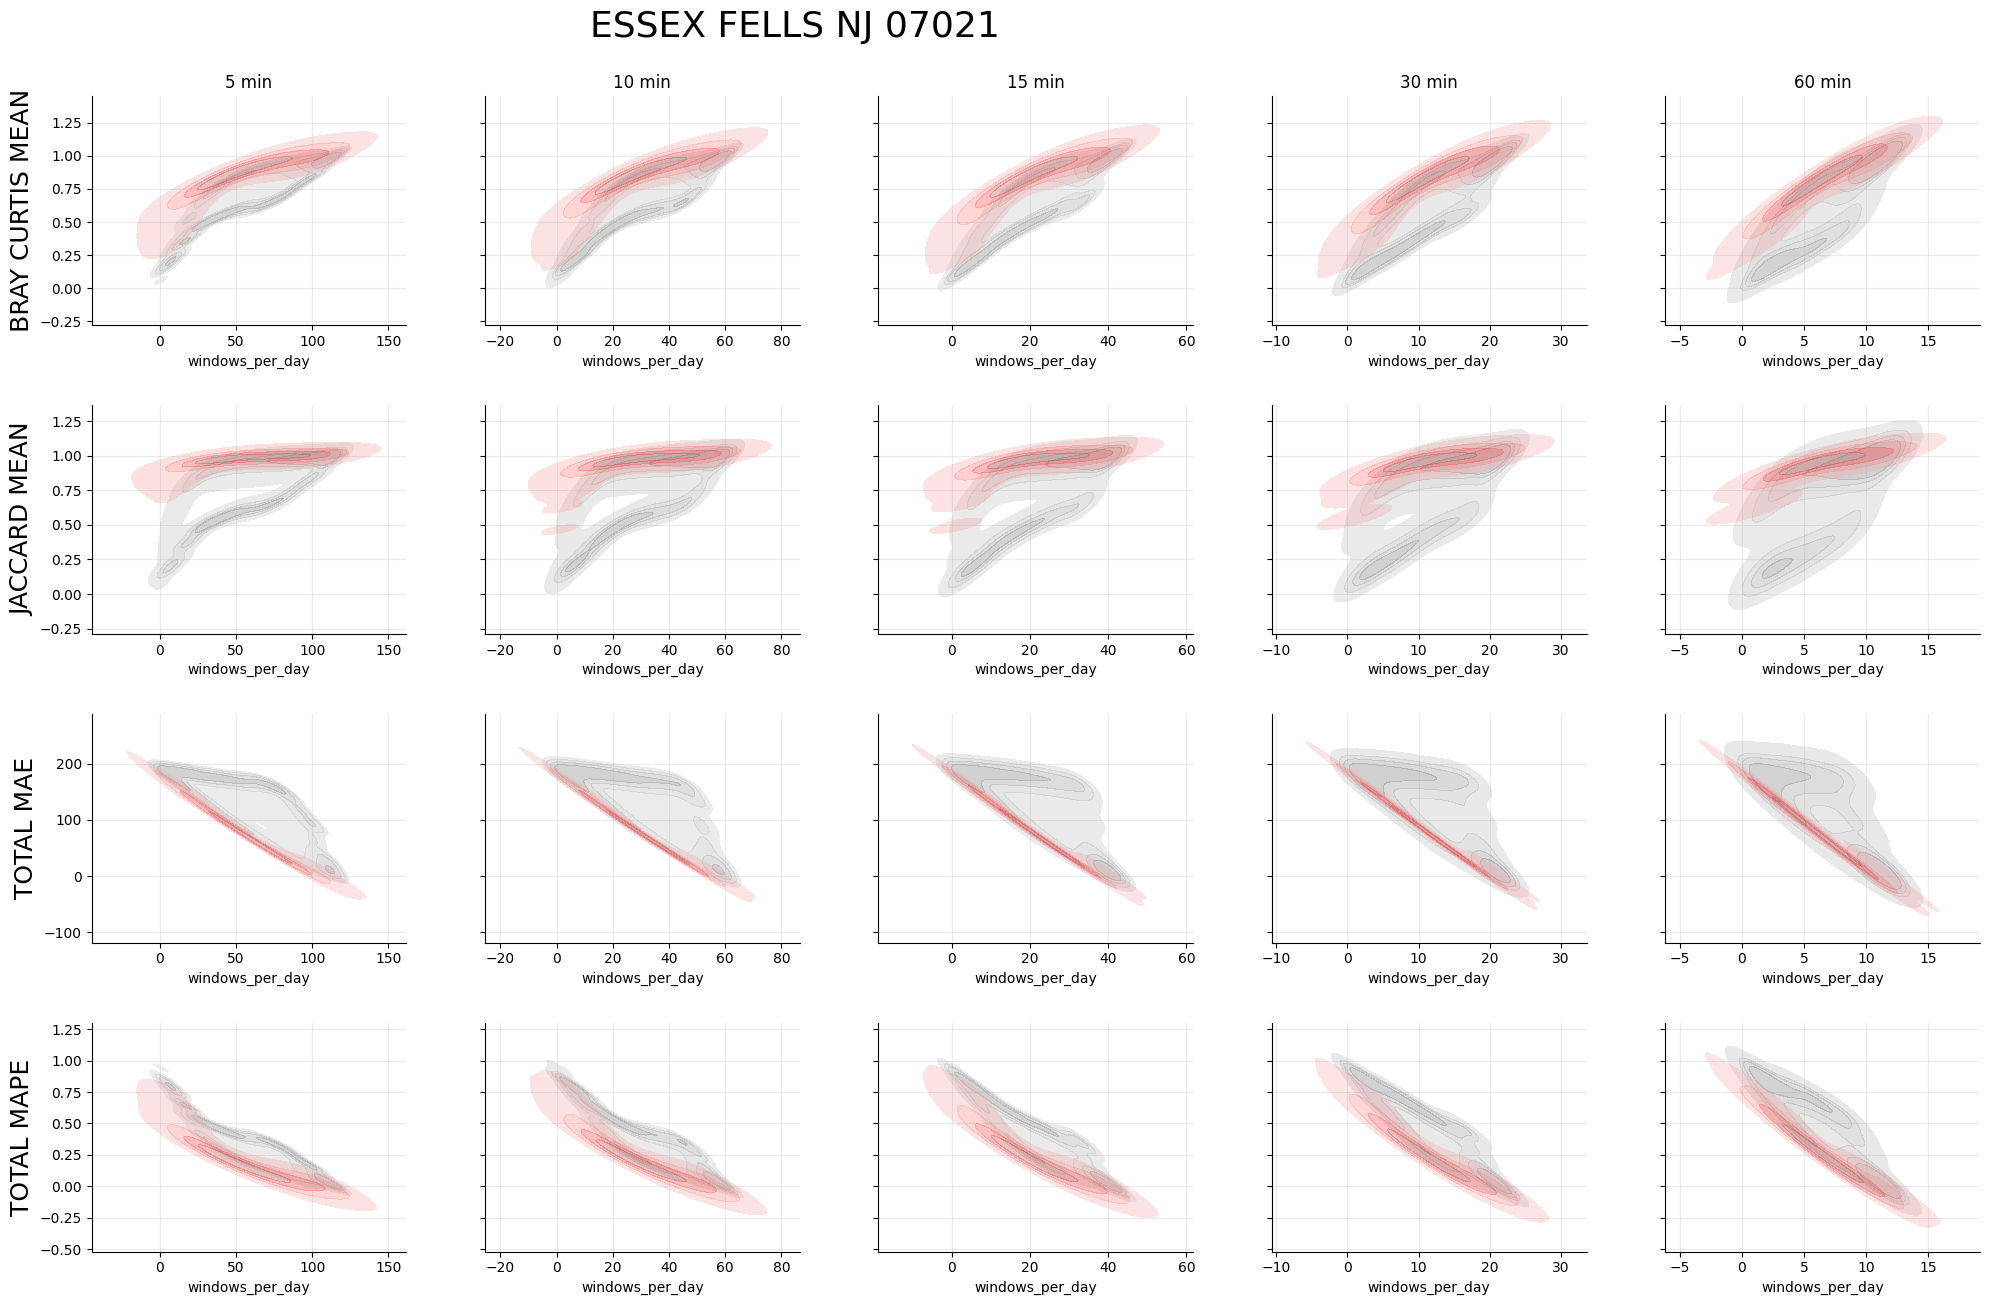

In [12]:
for site in pareto_results["site"].unique():
    plot_pareto_subplots_for_site(site, all_results, pareto_results, annotate_k=5)

## Weekly strategy

In [ ]:
# --- Weekly sampling simulation: days/week × block length × random vs systematic ---
# Goal: What weekly regimen (1–7 days, 240/300/360 min blocks) best captures total species diversity?
# Strategies: random block placement vs systematic (early, middle, late coverage across the week).

# Ensure we have prepared df and week labels
if 'df' not in dir():
    df = prepare_df(time_sampling)
df_week = df.copy()
dt = pd.to_datetime(df_week["Date"])
df_week["year"] = dt.dt.isocalendar().year
df_week["week"] = dt.dt.isocalendar().week
df_week["year_week"] = df_week["year"].astype(str) + "_W" + df_week["week"].astype(str)

BLOCK_MINUTES = [240, 300, 360]
DAYS_PER_WEEK = list(range(1, 8))
RANDOM_SEEDS = 15  # repeat random strategy and average

def get_truth_and_span(g: pd.DataFrame):
    """Species set and activity span (min, max minute_of_day) for a site-week."""
    truth = set(g["Bird"].dropna().unique())
    if g["minute_of_day"].empty:
        return truth, 0, 0
    first_bird = int(g["minute_of_day"].min())
    last_bird = int(g["minute_of_day"].max())
    return truth, first_bird, last_bird

def systematic_starts(first_bird: int, last_bird: int, block_min: int, n_days: int) -> list:
    """Place n_days blocks of length block_min in [first_bird, last_bird]: first at start, last at end, evenly spaced."""
    span = last_bird - first_bird
    if span < block_min or n_days <= 0:
        return [first_bird] if n_days >= 1 else []
    if n_days == 1:
        return [first_bird + max(0, (span - block_min) // 2)]  # center the single block
    step = (span - block_min) / max(1, n_days - 1)
    return [int(first_bird + i * step) for i in range(n_days)]

def species_in_window(g: pd.DataFrame, start_min: int, end_min: int) -> set:
    """Species seen in g with minute_of_day in [start_min, end_min)."""
    mask = (g["minute_of_day"] >= start_min) & (g["minute_of_day"] < end_min)
    return set(g.loc[mask, "Bird"].dropna().unique())

def run_one_week_random(
    g: pd.DataFrame, truth: set, first_bird: int, last_bird: int,
    n_days: int, block_min: int, seed: int
) -> float:
    """Random strategy: n_days random days, each with a random contiguous block of block_min. Returns proportion captured."""
    rng = np.random.default_rng(seed)
    dates = g["Date"].unique()
    if len(dates) < n_days:
        return np.nan
    chosen_dates = rng.choice(dates, size=n_days, replace=False)
    span = max(block_min, last_bird - first_bird)
    start_max = last_bird - block_min
    if start_max < first_bird:
        start_max = first_bird
    sampled = set()
    for d in chosen_dates:
        gd = g[g["Date"] == d]
        if gd.empty:
            continue
        fb, lb = int(gd["minute_of_day"].min()), int(gd["minute_of_day"].max())
        start_hi = max(fb, lb - block_min)
        if start_hi < fb:
            start_hi = fb
        start = int(rng.integers(fb, start_hi + 1)) if start_hi >= fb else fb
        end = min(start + block_min, 1440)
        sampled |= species_in_window(gd, start, end)
    return len(sampled & truth) / len(truth) if truth else np.nan

def run_one_week_systematic(
    g: pd.DataFrame, truth: set, first_bird: int, last_bird: int,
    n_days: int, block_min: int
) -> float:
    """Systematic: n_days blocks placed early/middle/late across span; assign to first n_days calendar days."""
    starts = systematic_starts(first_bird, last_bird, block_min, n_days)
    if not starts:
        return np.nan
    dates = sorted(g["Date"].unique())
    if len(dates) < n_days:
        return np.nan
    sampled = set()
    for i, d in enumerate(dates[:n_days]):
        if i >= len(starts):
            break
        gd = g[g["Date"] == d]
        s, e = starts[i], starts[i] + block_min
        sampled |= species_in_window(gd, s, e)
    return len(sampled & truth) / len(truth) if truth else np.nan

# Build list of (site, year_week) with enough days
site_weeks = (
    df_week.groupby(["source_sheet", "year_week"])
    .filter(lambda x: x["Date"].nunique() >= 1)
    .groupby(["source_sheet", "year_week"])
)
rows = []
for (site, yw), grp in site_weeks:
    truth, first_bird, last_bird = get_truth_and_span(grp)
    if not truth or last_bird <= first_bird:
        continue
    n_days_avail = grp["Date"].nunique()
    for block_min in BLOCK_MINUTES:
        for n_days in DAYS_PER_WEEK:
            if n_days > n_days_avail:
                continue
            # Systematic
            p_sys = run_one_week_systematic(grp, truth, first_bird, last_bird, n_days, block_min)
            rows.append({"site": site, "year_week": yw, "n_days": n_days, "block_min": block_min, "strategy": "systematic", "prop_captured": p_sys})
            # Random (average over seeds)
            props_rand = [
                run_one_week_random(grp, truth, first_bird, last_bird, n_days, block_min, seed)
                for seed in range(RANDOM_SEEDS)
            ]
            props_rand = [x for x in props_rand if not np.isnan(x)]
            p_rand = np.mean(props_rand) if props_rand else np.nan
            rows.append({"site": site, "year_week": yw, "n_days": n_days, "block_min": block_min, "strategy": "random", "prop_captured": p_rand})

weekly_results = pd.DataFrame(rows)
weekly_results

In [ ]:
# Aggregate: mean proportion of species captured by regimen (n_days, block_min, strategy)
agg = (
    weekly_results.dropna(subset=["prop_captured"])
    .groupby(["n_days", "block_min", "strategy"], as_index=False)["prop_captured"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
agg.rename(columns={"mean": "prop_captured_mean", "std": "prop_captured_std", "count": "n"}, inplace=True)
agg["block_min"] = agg["block_min"].astype(int)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for (block_min, strategy), g in agg.groupby(["block_min", "strategy"]):
    g = g.sort_values("n_days")
    label = f"{block_min} min, {strategy}"
    ax.plot(g["n_days"], g["prop_captured_mean"], "o-", label=label)
    ax.fill_between(
        g["n_days"],
        g["prop_captured_mean"] - g["prop_captured_std"].fillna(0),
        g["prop_captured_mean"] + g["prop_captured_std"].fillna(0),
        alpha=0.2,
    )
ax.set_xlabel("Days per week")
ax.set_ylabel("Mean proportion of weekly species captured")
ax.set_title("Weekly sampling: effect of days/week, block length, and placement (random vs systematic)")
ax.legend(loc="lower right", fontsize=8)
ax.set_xticks(DAYS_PER_WEEK)
ax.set_ylim(0, 1.05)
sns.despine()
plt.tight_layout()
plt.show()
agg

Add here